<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
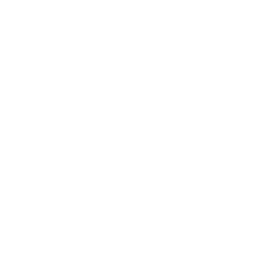
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Análise de Similaridade de Currículo</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Ensino Superior / Desenho de Programa Acadêmico &nbsp;|&nbsp; Março de 2026</p>
</div>
</div>
</div>

## Resumo executivo

Este notebook mede a sobreposição de currículos em um catálogo
universitário de disciplinas usando **PROC DISTANCE** com **METHOD=DJACCARD** — o
coeficiente de *dissimilaridade* de Jaccard, a distância natural para dados
binários de presença/ausência. Cada disciplina carrega 40 sinalizadores binários que marcam
quais resultados de aprendizagem de acreditação ela cobre, portanto a distância de Jaccard
entre duas disciplinas é a fração de resultados cobertos que elas **não**
têm em comum (0 = conjuntos de resultados idênticos, 1 = nenhum resultado compartilhado).

A análise ocorre em duas partes. Primeiro, ao longo de um catálogo de 100 disciplinas, ela
perfila a amplitude de cobertura de resultados por departamento (PROC MEANS, PROC FREQ,
um box plot de cobertura) e sinaliza os resultados de aprendizagem que **nenhuma** disciplina de um
departamento cobre (lacunas de cobertura). Segundo, ela aprofunda em um painel focado de
10 disciplinas retirado dos dois departamentos com maior sobreposição quantitativa
— Estatística e Ciência de Dados — calcula a matriz completa de distâncias de Jaccard par a par,
e classifica os pares de disciplinas mais próximos como
candidatos à revisão de consolidação. O objetivo é dar a um comitê curricular
dois artefatos concretos: uma lista classificada das disciplinas mais similares
e um mapa de lacunas por departamento e resultado.

## Fontes de dados

| Fonte | Descrição | Registros |
|--------|-------------|---------|
| WORK.COURSE_OUTCOMES | Cobertura binária de resultados de aprendizagem por disciplina (40 sinalizadores de resultado) | 100 |
| WORK.PANEL10 | Painel de consolidação de Estatística + Ciência de Dados | 10 |

O catálogo é sintético. Os sinalizadores de resultado são sorteados com
probabilidades específicas por departamento, de modo que as disciplinas enfatizem
diferentes agrupamentos de resultados (ciência da computação e matemática ponderam os
resultados iniciais, as ciências de laboratório ponderam a faixa central), dando à
análise de distância uma estrutura realista. Este ambiente roda sem licença,
portanto o catálogo de trabalho é limitado a 100 disciplinas.

---

In [1]:
/* --------------------------------------------------------
   Gerar matriz sintética de resultados de aprendizagem por
   disciplina: 500 disciplinas x 40 resultados de acreditação
   (o modo sem licença mantém as primeiras 100)
   -------------------------------------------------------- */
DADOS work.course_outcomes;
    CHAMAR streaminit(42);
    VETOR outcomes[40] lo_1 - lo_40;
    VETOR dept_list[8] $15 _temporary_ ('CIENCIA_COMP' 'MATEMATICA' 'ESTATISTICA' 'ENGENHARIA' 'BIOLOGIA' 'QUIMICA' 'FISICA' 'CIENCIA_DADOS');
    FAZER course_id = 1 ATÉ 500;
        course_label = cat('CRS', PUT(course_id, z4.));
        dept_idx = int(rand('uniform') * 8) + 1;
        department = dept_list[dept_idx];
        /* O nível da disciplina afeta a amplitude de resultados */
        course_level = int(rand('uniform') * 4) + 1;
        level_code = course_level * 100;
        /* Agrupamentos de resultados específicos por departamento */
        FAZER lo = 1 ATÉ 40;
            base_prob = 0.15;
            /* Dept 1-2 (Ciência Comp., Matemática): enfatiza resultados 1-15 */
            SE dept_idx <= 2 E_LÓGICO lo <= 15 ENTÃO
                base_prob = 0.4 + course_level * 0.05;
            /* Dept 3-4 (Estatística, Engenharia): enfatiza resultados 10-25 */
            SENÃO SE dept_idx IN (3, 4) E_LÓGICO 10 <= lo <= 25 ENTÃO
                base_prob = 0.35 + course_level * 0.05;
            /* Dept 5-7 (Biologia, Química, Física): enfatiza 20-35 */
            SENÃO SE dept_idx IN (5, 6, 7) E_LÓGICO 20 <= lo <= 35 ENTÃO
                base_prob = 0.38 + course_level * 0.04;
            /* Dept 8 (Ciência de Dados): cobertura ampla */
            SENÃO SE dept_idx = 8 ENTÃO
                base_prob = 0.25 + course_level * 0.03;
            outcomes[lo] = (rand('uniform') < base_prob);
        FIM;
        SAÍDA;
    FIM;
    REMOVER dept_idx course_level base_prob lo;
    RÓTULO department='Departamento' course_label='Disciplina'
          level_code='Nível' total_outcomes='Resultados Cobertos';
EXECUTAR;


NOTE: DATA work.course_outcomes

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.course_outcomes (100 rows, 44 columns).
NOTE: DATA elapsed:
  wall  1.81 seconds
  cpu   1.81 seconds


In [2]:
/* --------------------------------------------------------
   Gerar metadados do catálogo de disciplinas
   -------------------------------------------------------- */
DADOS work.course_catalog;
    CHAMAR streaminit(43);
    VETOR dept_list[8] $15 _temporary_ ('CIENCIA_COMP' 'MATEMATICA' 'ESTATISTICA' 'ENGENHARIA' 'BIOLOGIA' 'QUIMICA' 'FISICA' 'CIENCIA_DADOS');
    VETOR format_list[3] $12 _temporary_ ('PALESTRA' 'LABORATORIO' 'SEMINARIO');
    FAZER course_id = 1 ATÉ 500;
        course_label = cat('CRS-', PUT(course_id, z4.));
        dept_idx = int(rand('uniform') * 8) + 1;
        department = dept_list[dept_idx];
        level_code = (int(rand('uniform') * 4) + 1) * 100;
        credit_hours = int(rand('uniform') * 3) + 2;
        format_idx = int(rand('uniform') * 3) + 1;
        delivery_format = format_list[format_idx];
        enrollment_cap = int(rand('uniform') * 150) + 20;
        avg_enrollment = int(enrollment_cap * (rand('uniform') * 0.5 + 0.4));
        last_offered = '01JAN2025'd + int(rand('uniform') * 365);
        SAÍDA;
    FIM;
    REMOVER dept_idx format_idx;
    FORMATO last_offered date9.;
    RÓTULO department='Departamento' course_label='Disciplina'
          level_code='Nível' delivery_format='Formato de Aula'
          credit_hours='Créditos' enrollment_cap='Vagas'
          avg_enrollment='Matrícula Média';
EXECUTAR;


NOTE: DATA work.course_catalog

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.course_catalog (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.09 seconds
  cpu   0.09 seconds


---

                                     Cobertura Média de Resultados por Departamento                                     

                                                  The MEANS Procedure

                                               Analysis Variable : lo_1

                                                             N
                                          Departamento     Obs           Mean
                                          -----------------------------------
                                          BIOLOGIA          10      0.2000000
                                          CIENCIA_COMP      13      0.3846154
                                          CIENCIA_DADOS     14      0.1428571
                                          ENGENHARIA        17      0.0000000
                                          ESTATISTICA       11      0.0909091
                                          FISICA             7      0.2857143
                                          MATEM


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_department_level_code.spec.json
NOTE: PROC FREQ statement used.


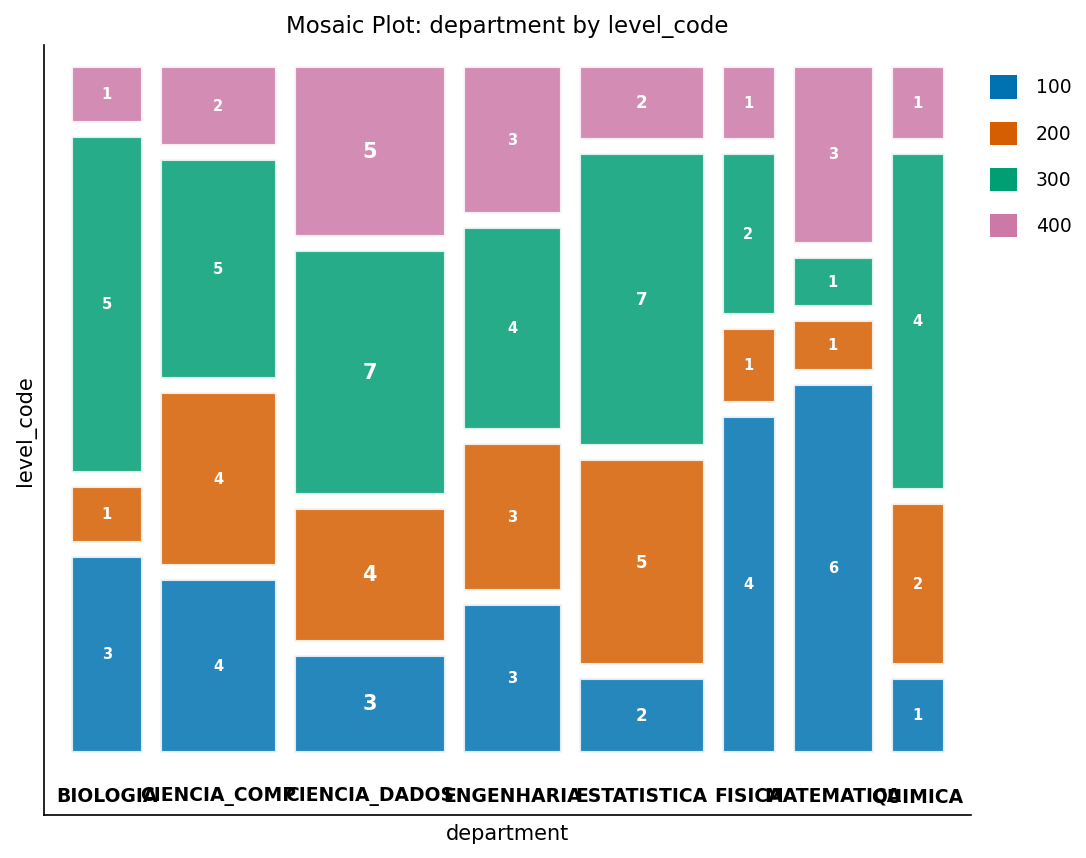

In [3]:
/* --------------------------------------------------------
   Cobertura de resultados de aprendizagem de base por departamento
   -------------------------------------------------------- */
PROCEDIMENTO MÉDIAS DADOS=work.course_outcomes mean;
    CLASSE department;
    VARIÁVEL lo_1 - lo_40;
    RÓTULO department='Departamento';
    TÍTULO 'Cobertura Média de Resultados por Departamento';
EXECUTAR;

PROCEDIMENTO FREQUÊNCIAS DADOS=work.course_catalog;
    TABLES department * level_code / nopercent norow nocol;
    RÓTULO department='Departamento' level_code='Nível';
    TÍTULO 'Contagem de Disciplinas por Departamento e Nível';
EXECUTAR;

---

                                    Contagem de Disciplinas por Departamento e Nível                                    




NOTE: DATA work.outcome_counts


NOTE: Read 100 rows from work.course_outcomes.
NOTE: Wrote work.outcome_counts (100 rows, 45 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds
NOTE: PROC SGPLOT data=work.outcome_counts

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


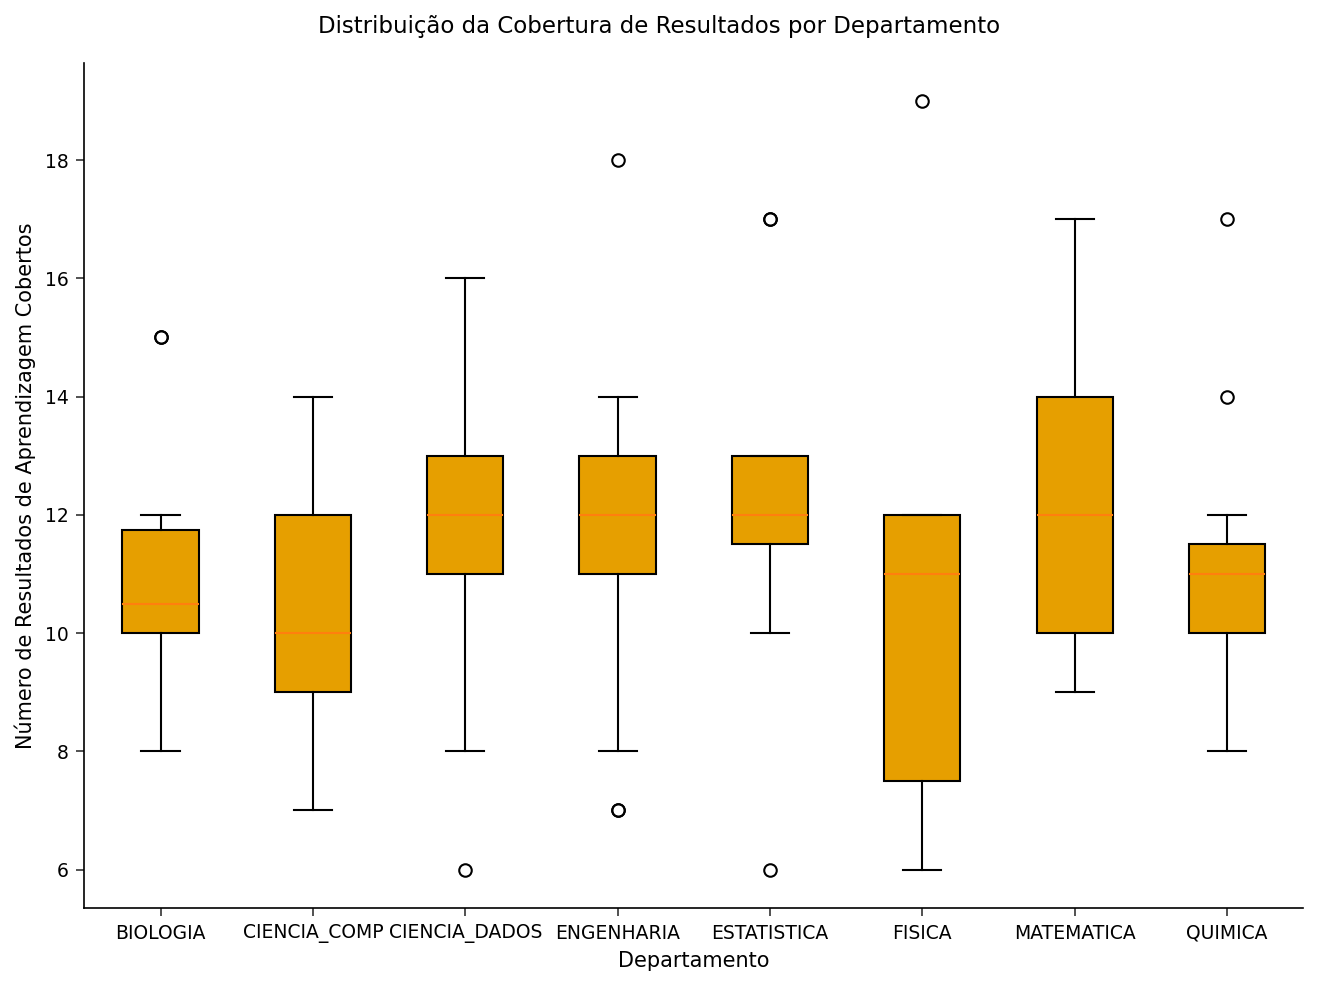

In [4]:
/* --------------------------------------------------------
   Densidade de cobertura de resultados por departamento
   -------------------------------------------------------- */
DADOS work.outcome_counts;
    DEFINIR work.course_outcomes;
    VETOR outcomes[40] lo_1 - lo_40;
    total_outcomes = sum(OF outcomes[*]);
    RÓTULO total_outcomes='Resultados de Aprendizagem Cobertos'
          department='Departamento';
EXECUTAR;

PROCEDIMENTO SGPLOT DADOS=work.outcome_counts;
    VBOX total_outcomes / category=department;
    YAXIS RÓTULO='Número de Resultados de Aprendizagem Cobertos';
    XAXIS RÓTULO='Departamento';
    TÍTULO 'Distribuição da Cobertura de Resultados por Departamento';
EXECUTAR;

---

In [5]:
/* --------------------------------------------------------
   Painel de consolidação: as primeiras 10 disciplinas de
   Estatística / Ciência de Dados (os dois departamentos com
   maior sobreposição quantitativa). Renomeie-as P01-P10 com
   um contador sequencial para que a matriz quadrada de
   distâncias OUT= tenha colunas limpas e endereçáveis; então
   calcule a matriz completa de distâncias de Jaccard par a par
   com METHOD=DJACCARD
   (0 = conjuntos de resultados idênticos, 1 = nenhum compartilhado).
   -------------------------------------------------------- */
DADOS work.panel10;
    DEFINIR work.course_outcomes(ONDE=(department IN ('ESTATISTICA' 'CIENCIA_DADOS')));
    RETER seq 0;
    seq + 1;
    SE seq > 10 ENTÃO PARAR;
    panel_id = cat('P', PUT(seq, z2.));
    REMOVER seq;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=work.panel10 noobs RÓTULO;
    VARIÁVEL panel_id course_label department level_code;
    RÓTULO panel_id = 'ID do Painel' course_label = 'Disciplina'
          department = 'Departamento' level_code = 'Nível';
    TÍTULO 'Painel de Consolidação: Disciplinas de Estatística e Ciência de Dados';
EXECUTAR;

PROCEDIMENTO distance DADOS=work.panel10
              out=work.panel_dist
              METHOD=djaccard;
    VARIÁVEL nominal(lo_1 - lo_40);
    id panel_id;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=work.panel_dist noobs;
    TÍTULO 'Matriz de Distâncias de Jaccard Par a Par (10 Disciplinas)';
EXECUTAR;

                         Painel de Consolidação: Disciplinas de Estatística e Ciência de Dados                          

ID do Painel  Disciplina   Departamento   Nível
P01           CRS0003     CIENCIA_DADOS     300
P02           CRS0006     ESTATISTICA       300
P03           CRS0014     CIENCIA_DADOS     300
P04           CRS0015     ESTATISTICA       300
P05           CRS0017     ESTATISTICA       200
P06           CRS0019     CIENCIA_DADOS     100
P07           CRS0022     ESTATISTICA       400
P08           CRS0033     CIENCIA_DADOS     200
P09           CRS0038     ESTATISTICA       100
P10           CRS0040     ESTATISTICA       100

                         Painel de Consolidação: Disciplinas de Estatística e Ciência de Dados                          

                               Matriz de Distâncias de Jaccard Par a Par (10 Disciplinas)                               

_NAME_           P01           P02           P03           P04           P05           P06           P07 


NOTE: DATA work.panel10


NOTE: Read 41 rows from work.course_outcomes.
NOTE: Wrote work.panel10 (10 rows, 45 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC PRINT data=work.panel10

NOTE: PROC PRINT completed: 10 observations printed, 4 variables
NOTE: PROC DISTANCE data=work.panel10 method=Djaccard

NOTE: PROC DISTANCE: 10 observations, 40 variables, method=Djaccard
NOTE: PROC PRINT data=work.panel_dist

NOTE: PROC PRINT completed: 10 observations printed, 11 variables


In [6]:
/* --------------------------------------------------------
   Remodelar a matriz quadrada de distâncias em uma lista
   classificada de pares de disciplinas. As colunas de distância
   OUT= são endereçadas por uma lista explícita de nomes
   (P01 P02 ... P10); apenas o triângulo superior estrito
   (col > row) é mantido para que cada par não ordenado apareça
   uma vez e a diagonal zero seja ignorada. Os cinco pares mais
   próximos são os candidatos à revisão de consolidação.
   -------------------------------------------------------- */
DADOS work.similar_courses;
    DEFINIR work.panel_dist;
    VETOR d[10] P01 P02 P03 P04 P05 P06 P07 P08 P09 P10;
    COMPRIMENTO course_a course_b $8;
    course_a = _name_;
    row + 1;
    FAZER col = 1 ATÉ 10;
        SE col > row ENTÃO FAZER;
            course_b     = vname(d[col]);
            jaccard_dist = round(d[col], 0.001);
            SAÍDA;
        FIM;
    FIM;
    MANTER course_a course_b jaccard_dist;
EXECUTAR;

PROCEDIMENTO MÉDIAS DADOS=work.similar_courses n MIN q1 MEDIAN mean MAX maxdec=3;
    VARIÁVEL jaccard_dist;
    RÓTULO jaccard_dist='Distância de Jaccard';
    TÍTULO 'Distribuição das Distâncias de Jaccard Par a Par (45 Pares de Disciplinas)';
EXECUTAR;

PROCEDIMENTO ORDENAR DADOS=work.similar_courses; POR jaccard_dist; EXECUTAR;

DADOS work.top_pairs;
    DEFINIR work.similar_courses;
    pair_rank = _n_;
    SE pair_rank <= 5;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=work.top_pairs noobs RÓTULO;
    VARIÁVEL pair_rank course_a course_b jaccard_dist;
    RÓTULO pair_rank = 'Classificação' course_a = 'Disciplina A'
          course_b = 'Disciplina B' jaccard_dist = 'Distância de Jaccard';
    TÍTULO 'Cinco Pares de Disciplinas Mais Próximos (Candidatos à Consolidação)';
EXECUTAR;

                       Distribuição das Distâncias de Jaccard Par a Par (45 Pares de Disciplinas)                       

                                                  The MEANS Procedure

 Variable      Label                        N     Minimum   Lower Quartile      Median        Mean     Maximum
 -------------------------------------------------------------------------------------------------------------
 jaccard_dist  Distância de Jaccard        45       0.588            0.762       0.826       0.818       0.962
 -------------------------------------------------------------------------------------------------------------

                          Cinco Pares de Disciplinas Mais Próximos (Candidatos à Consolidação)                          

  Classificação  Disciplina A  Disciplina B   Distância de Jaccard
              1  P02           P10                           0.588
              2  P03           P04                             0.6
              3  P03           P05     


NOTE: DATA work.similar_courses


NOTE: Read 10 rows from work.panel_dist.
NOTE: Wrote work.similar_courses (45 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=work.similar_courses

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 45 rows from work.similar_courses.
NOTE: Wrote work.similar_courses (45 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.top_pairs


NOTE: Read 45 rows from work.similar_courses.
NOTE: Wrote work.top_pairs (5 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.top_pairs

NOTE: PROC PRINT completed: 5 observations printed, 4 variables


                                Resultados de Aprendizagem Não Cobertos por Departamento                                

                                                   The FREQ Procedure

Departamento    Frequency    Percent
-------------------------------------
BIOLOGIA                8     26.67
CIENCIA_COMP            3     10.00
ENGENHARIA              2      6.67
ESTATISTICA             3     10.00
FISICA                  8     26.67
MATEMATICA              4     13.33
QUIMICA                 2      6.67
                                 Amostra de Lacunas de Resultados (primeiras 12 de 30)                                  

Departamento   Resultado Não Coberto
BIOLOGIA      LO02
BIOLOGIA      LO10
BIOLOGIA      LO15
BIOLOGIA      LO16
BIOLOGIA      LO17
BIOLOGIA      LO18
BIOLOGIA      LO36
BIOLOGIA      LO37
CIENCIA_COMP  LO29
CIENCIA_COMP  LO35
CIENCIA_COMP  LO36
ENGENHARIA    LO01

... 18 more observations (showing 12 of 30)




NOTE: PROC MEANS
NOTE: Output dataset work.dept_coverage has 8 observations and 43 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.outcome_gaps


NOTE: Read 8 rows from work.dept_coverage.
NOTE: Wrote work.outcome_gaps (30 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_department.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC PRINT data=work.outcome_gaps

NOTE: PROC PRINT completed: 12 observations printed, 2 variables


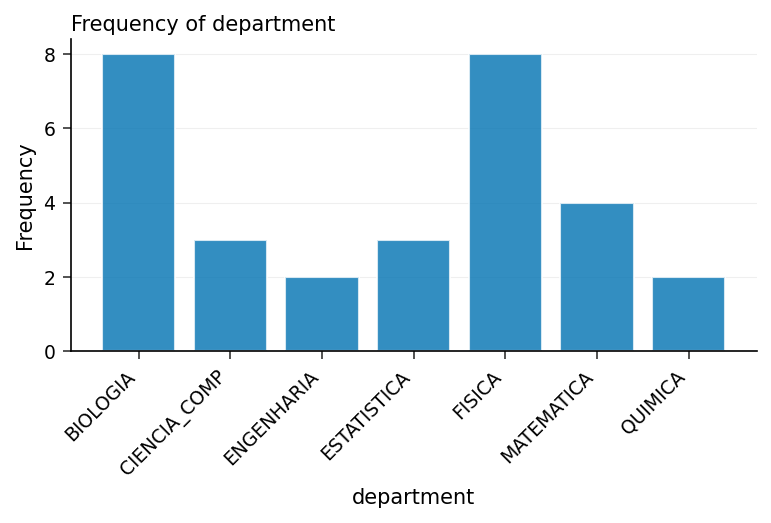

In [7]:
/* --------------------------------------------------------
   Lacunas de resultados: resultados de aprendizagem que
   NENHUMA disciplina de um departamento cobre. PROC MEANS soma
   cada sinalizador binário de resultado dentro do departamento;
   uma soma zero significa que o resultado está ausente do
   catálogo daquele departamento.
   -------------------------------------------------------- */
PROCEDIMENTO MÉDIAS DADOS=work.course_outcomes sum NOPRINT;
    CLASSE department;
    VARIÁVEL lo_1 - lo_40;
    SAÍDA out=work.dept_coverage(ONDE=(_type_=1))
        sum=lo_1 - lo_40;
EXECUTAR;

DADOS work.outcome_gaps;
    DEFINIR work.dept_coverage;
    VETOR outcomes[40] lo_1 - lo_40;
    FAZER lo = 1 ATÉ 40;
        outcome_id = cat('LO', PUT(lo, z2.));
        courses_covering = outcomes[lo];
        SE courses_covering = 0 ENTÃO FAZER;
            gap_flag = 1;
            SAÍDA;
        FIM;
    FIM;
    MANTER department outcome_id courses_covering gap_flag;
    RÓTULO department='Departamento' outcome_id='Resultado Não Coberto';
EXECUTAR;

PROCEDIMENTO FREQUÊNCIAS DADOS=work.outcome_gaps;
    TABLES department / nocum;
    RÓTULO department='Departamento';
    TÍTULO 'Resultados de Aprendizagem Não Cobertos por Departamento';
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=work.outcome_gaps(obs=12) noobs RÓTULO;
    VARIÁVEL department outcome_id;
    RÓTULO department = 'Departamento' outcome_id = 'Resultado Não Coberto';
    TÍTULO 'Amostra de Lacunas de Resultados (primeiras 12 de 30)';
EXECUTAR;

---

### Interpretação

**Painel de consolidação.** Ao longo dos 45 pares não ordenados no
painel de 10 disciplinas de Estatística / Ciência de Dados, a distância de Jaccard varia de
0.588 a 0.962 com mediana de 0.826 (média 0.818). O par
mais próximo é P02 e P10 à distância 0.588, seguido por
P03–P04 em 0.600 e P03–P05 em 0.667. Mesmo as disciplinas mais
similares ainda diferem em cerca de 59% de seus resultados
cobertos, portanto este catálogo não contém **nenhuma disciplina quase duplicada** — não
há par que um comitê pudesse fundir de imediato. Em vez disso, a lista classificada
aponta o punhado de pares que valem uma comparação manual de ementas antes
do próximo ciclo do catálogo; os pares de maior distância (perto de 0.962) confirmam
que as disciplinas de Estatística e Ciência de Dados, apesar de compartilharem uma vizinhança
departamental, abrangem conjuntos de resultados genuinamente distintos.

**Lacunas de resultados.** Trinta lacunas por departamento e resultado surgem ao longo do
catálogo. As disciplinas com forte carga laboratorial carregam mais: **Biologia** e
**Física** deixam cada uma 8 dos 40 resultados de acreditação sem cobertura,
seguidas por **Matemática** (4). Os departamentos quantitativos são os
mais bem cobertos — **Química** e **Engenharia** deixam de cobrir apenas 2 resultados
cada. Essas lacunas são os alvos naturais para o desenvolvimento de novas disciplinas ou
para a listagem cruzada: um resultado ausente de todo um departamento é um risco de
cobertura na renovação da acreditação, enquanto a lista de consolidação aborda
o problema oposto de esforço redundante. Juntos, os dois artefatos permitem
que o comitê aperte o catálogo pelas duas pontas — reduzindo a sobreposição e
preenchendo os vazios — usando uma única medida de distância baseada em conjuntos.

---

In [8]:
/* --------------------------------------------------------
   Exportar os candidatos à consolidação classificados e o
   mapa de lacunas de resultados por departamento para o
   comitê curricular.
   -------------------------------------------------------- */
PROCEDIMENTO EXPORT DADOS=work.similar_courses
    OUTFILE='curriculum_consolidation_candidates.csv'
    DBMS=csv REPLACE;
EXECUTAR;

PROCEDIMENTO EXPORT DADOS=work.outcome_gaps
    OUTFILE='curriculum_outcome_gaps.csv'
    DBMS=csv REPLACE;
EXECUTAR;


NOTE: PROC EXPORT data=work.similar_courses outfile=curriculum_consolidation_candidates.csv

NOTE: Exported 45 rows to curriculum_consolidation_candidates.csv.
NOTE: PROC EXPORT data=work.outcome_gaps outfile=curriculum_outcome_gaps.csv

NOTE: Exported 30 rows to curriculum_outcome_gaps.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Desenvolvido por <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>